# Hello world

Goal of notebook is to understand and investigate how:
* How well does a model perform with different data veracity 

* How is accuracy affected when corruption is introduced in evaluation- and training data?
* Sub-question: Does introducing corruption in training data increase performance when evaluating on corrupt data? 

To achive this a base from [imagenet](https://keras.io/api/applications/efficientnet/efficientnet_models/#efficientnetb0-function) with weights was used without toplayer together with [Stanford Dogs Dataset](http://vision.stanford.edu/aditya86/ImageNetDogs/) was used.

To create veracity in the trainingdata corruption was manually introduced with equal parts of jpeg compression, random noise to make the picture darker, and blur, where 0% , 50% and 100% of the training data was corrupted.

This was later evaluated on clean validation data and corrupted data of each type at the time with diffrent severity. The validation evaluation was done with Jpeg with 80%, 60%, 20% of original quality, noise with a shift from mean 10, 20, 30, and blur 3, 5, 8 how much the colors average out. 

public available:[Github repo](https://github.com/d21emijo/BDP/blob/main/notebooks/notebook.ipynb)

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter
import time
import os
import pandas as pd


# Train/val split

* Split the data with 20% of the data as validation
* Batch size standard 32
* Img size as 224,224 since imagenet trained on 224*224
* Seed 1337 for reproducibility


In [3]:
Data_DIR = "../data/images/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 1337
Epochs = 5

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    Data_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",

)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    Data_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",

)

class_names = train_ds_raw.class_names
num_classes = len(class_names)


train_ds = train_ds_raw
val_ds = val_ds_raw


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [4]:
print(IMG_SIZE + (3,), BATCH_SIZE, SEED)


(224, 224, 3) 32 1337


## Corrupt

* Corrupt diffrent amount of the training data to se how sensitive the model is.
* Evaluate the model on corrupt data to se how robust the model is.


### Random noice

* Change random pixels from the standard 255 colors by changing the values by the mean
* a negative mean value will give darker pixels since 0,0,0 is black and a positive mean will skew the imges to brighter pictures.

In [5]:
def add_noise(img, std=255.0, mean=-50.0):
    if len(img.shape) == 4:
        return tf.map_fn(lambda x: add_noise(x, std, mean), img, fn_output_signature=tf.float32)
    noise = tf.random.normal(tf.shape(img), mean=mean, stddev=std)
    return tf.clip_by_value(img + noise, 0.0, 255.0)

# val_ds_noise = (val_ds_raw
#                 .map(lambda img, label: add_noise(img, label, std=40.0)))

### Jpeg compression

* cast to convert to 0-255
* convert to x using a encode_jpeg, now a compressed byte string from img with a quality from 0-100.
* decode converts back to img but with quality loss with rgd channels.
* cast makes the image a tensor again.

In [6]:
def jpeg_compression(img, quality=75):
    # Handle both single images (rank 3) and batches (rank 4)
    if len(img.shape) == 4:
        return tf.map_fn(
            lambda x: jpeg_compression(x, quality),
            img,
            fn_output_signature=tf.float32
        )
    img = tf.cast(img, tf.uint8)
    encoded = tf.io.encode_jpeg(img, quality=quality)
    decoded = tf.io.decode_jpeg(encoded, channels=3)
    return tf.cast(decoded, tf.float32)


# val_ds_jpeg = (val_ds_raw
#                .unbatch()
#                .map(lambda x, y: jpeg_compression(x, y),)
#                .batch(BATCH_SIZE))

### Blur

* expand_dims to create correct format for avg_pool2d = 1(picture from batch),224(height),224(witdth),3(colors)
* ksize=k how many pixels should be avaraged out, k*k mean, stride=how many pixels to move each time
* squeeze to remove first dimension

In [7]:
def blur(img, k=5):
    if len(img.shape) == 4:
        return tf.map_fn(lambda x: blur(x, k), img, fn_output_signature=tf.float32)
    img4 = tf.expand_dims(img, 0)
    img4 = tf.nn.avg_pool2d(img4, ksize=k, strides=1, padding="SAME")
    return tf.squeeze(img4, 0)

# val_ds_blur = (val_ds_raw
#                .unbatch()
#                .map(lambda x, y: blur(x, y),)
#                .batch(BATCH_SIZE))


## Corrupt some input data

* corrupt part of the data based on p
* unbatch and give each image , a index with enumerate
* i = index , data = img and label
* use random.stateless_uniform to create same random nr each time based on indecis.
* corrupt if r < p
* map to all apply chance to all images

### mixed corruption

* img index i as seed
* corrupts a 1/3 of data to blur,noice and jpeg each based on stateless generator


In [8]:
def corrupt_fraction(train_ds_raw, corrupt_fn, p=0.5, seed=SEED, batch_size=32, shuffle=True):
    ds = train_ds_raw.unbatch().enumerate()

    def maybe_corrupt(i, data):
        img, label = data

        r = tf.random.stateless_uniform( # create a random number generator that is deterministic based on the seed and index
            shape=[],
            seed=tf.stack([tf.cast(seed, tf.int32), tf.cast(i, tf.int32)]),
        )

        corrupted_img = tf.cond(
            r < p,
            lambda: corrupt_fn(i, img),  # only pass index + image
            lambda: img
        )
        return corrupted_img, label  # label always passed through unchanged

    ds = ds.map(maybe_corrupt)
    ds = ds.batch(batch_size)
    return ds

In [9]:
def mixed_corruption(i, img):
    i = tf.cast(i, tf.int32)

    r_type = tf.random.stateless_uniform(
        shape=[],
        seed=tf.stack([tf.constant(SEED + 1, tf.int32), i])
    )

    return tf.case(
        [
            (r_type < 1/3, lambda: blur(img, k=5)),
            (r_type < 2/3, lambda: add_noise(img, std=25.0)),
        ],
        default=lambda: jpeg_compression(img, quality=30),
        exclusive=False
    )

# Build model


EfficentNetB0 is based on images from the imagenet database containing 1000 categories including dogbreeds some over 1m pictures.
* include_top=False to ignore efficientnet classification, but we keep the feature extraction
* weights="imagenet" keep their pretrained weights for those features.
* 224 * 224 * 3, w,b,colors
* base.trainable = False to keep only using imagenet features
* inputs get w,b,c input > preprocess_input scales to correct format > x = base(x, training=False) feature representation from imagenet
* GlobalAveragePooling2D`` takes avarage and makes it 1d vector
* outputs creates a value from 0-1 by using softmax for each of the 120 classes

* use adam as optimizer with a learning rate of 0.001
* SparseCategoricalCrossentropy CategoricalCrossentropy since we have a int for our dog classses, then predicts a probability for all dog classes.



In [10]:
def build_model():
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, 
        weights="imagenet", 
        input_shape=IMG_SIZE + (3,)
    )
    base.trainable = False 

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)  # preprocess the input images using the same preprocessing as EfficientNet
    x = base(x, training=False) # create a feature map using the EfficientNet base
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs) 

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(), 
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
        ],
    )
    return model

## logg values

* callback for tensorboard

### predictions

* Save for predictions and probability

### Diffrent evaluations

* Evaluate with Jpeg,  100 is original img
* Evaluate with noise,  0 is original img
* Evaluate with blur,  1 is original image

In [11]:
def make_callbacks(corruption_name, p):
    run_name = f"{corruption_name}_p{int(p*100)}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    log_dir = os.path.join("logs", run_name)

    tb = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=0,
        write_graph=True,
        update_freq="batch",
        profile_batch=0
    )

    return [tb], log_dir

In [12]:
def collect_predictions(model, ds):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in ds:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

In [13]:
def preprocess_for_model(x):
    x = tf.cast(x, tf.float32)
    return x

def make_corrupted(ds, corrupt_fn):
    return ds.map(
        lambda x, y: (corrupt_fn(preprocess_for_model(x)), y)
    ).prefetch(tf.data.AUTOTUNE)

def evaluate_model(model, val_ds,p):
    results = []

    clean_ds = val_ds.map(lambda x,y: (preprocess_for_model(x), y)).prefetch(AUTOTUNE)
    clean_metrics = model.evaluate(clean_ds, verbose=0, return_dict=True)
    results.append({
        "p": p,
        "corruption_type": "clean",
        "severity": None,
        "loss": clean_metrics["loss"],
        "accuracy": clean_metrics["accuracy"],
        "top5": clean_metrics["top5"],
    })

    for sigma in [10, 20, 30]:
        ds_c = make_corrupted(val_ds, lambda x: add_noise(x, sigma))
        metrics = model.evaluate(ds_c, verbose=0, return_dict=True)
        results.append({
            "p": p,
            "corruption_type": "noise",
            "severity": sigma,
            "loss": metrics["loss"],
            "accuracy": metrics["accuracy"],
            "top5": metrics["top5"],
        })

    for q in [80, 60, 20]:
        ds_c = make_corrupted(val_ds, lambda x, q=q: jpeg_compression(x, q))
        metrics = model.evaluate(ds_c, verbose=0, return_dict=True)
        results.append({
            "p": p,
            "corruption_type": "jpeg",
            "severity": q,
            "loss": metrics["loss"],
            "accuracy": metrics["accuracy"],
            "top5": metrics["top5"],
        })

    for k in [3, 5, 8,]:
        ds_c = make_corrupted(val_ds, lambda x: blur(x,k))
        metrics = model.evaluate(ds_c, verbose=0, return_dict=True)
        results.append({
            "p": p,
            "corruption_type": "blur",
            "severity": k,
            "loss": metrics["loss"],
            "accuracy": metrics["accuracy"],
            "top5": metrics["top5"],
        })

    return results

## Build models

* Build diffrent models for diffrent corrupt values
* take traindata and run corrupt fraction to get a % of corrupt pictures
* If the picture is choosen to be corrupt corrupt_fn=mixed_corruption chooses the type of corruption. 

In [14]:
results = []
predictions_store = []
corruption_levels = [0,0.5,1]
all_model_results = []


for p in corruption_levels:
    print(f"Training with {(p*100)}% corrupted images with")


    train_variant = corrupt_fraction(
        train_ds_raw,
        corrupt_fn=mixed_corruption,
        p=p,
        seed=SEED,
        batch_size=BATCH_SIZE,
    )

    model = build_model()
    callbacks, log_dir = make_callbacks("mixed", p)

    start = time.perf_counter()

    history = model.fit(
        train_variant,
        validation_data=val_ds,
        epochs=Epochs,
        callbacks=callbacks
    )
    
    model_results = evaluate_model(model, val_ds,p)
    all_model_results.extend(model_results)

    
    train_time = time.perf_counter() - start

    
    y_true, y_pred, y_prob = collect_predictions(model, val_ds)

    predictions_store.append({
        "corruption_type": "mixed",
        "p": p,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    })

    # val_loss, val_top1, val_top5 = model.evaluate(val_ds, verbose=0)

    # results.append({
    #     "corruption_type": "mixed",
    #     "percent": p * 100,
    #     "loss": val_loss,
    #     "val_top1": val_top1,
    #     "val_top5": val_top5,
    #     "log_dir": log_dir
    # })


Training with 0% corrupted images with
Epoch 1/5
    515/Unknown 104s 195ms/step - accuracy: 0.5529 - loss: 2.2521 - top5: 0.7890

c:\Users\Emil\Desktop\skola\BDP\BDP\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 130s 245ms/step - accuracy: 0.7182 - loss: 1.3157 - top5: 0.9237 - val_accuracy: 0.8450 - val_loss: 0.5750 - val_top5: 0.9852
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.8647 - loss: 0.4933 - top5: 0.9894 - val_accuracy: 0.8520 - val_loss: 0.4822 - val_top5: 0.9883
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 118s 229ms/step - accuracy: 0.8909 - loss: 0.3797 - top5: 0.9926 - val_accuracy: 0.8591 - val_loss: 0.4541 - val_top5: 0.9886
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 117s 228ms/step - accuracy: 0.9091 - loss: 0.3172 - top5: 0.9958 - val_accuracy: 0.8630 - val_loss: 0.4414 - val_top5: 0.9876
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 118s 228ms/step - accuracy: 0.9250 - loss: 0.2647 - top5: 0.9974 - val_accuracy: 0.8649 - val_loss: 0.4331 - val_top5: 0.9881
Training with 50.0% corrupted images with
Epoch 1/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 124s 233ms/step - accuracy: 0.6458 - loss: 1.5777 - top5: 0.8853 - val_accuracy: 0.8304 - val_loss: 0.61

### Create df from resualts

In [15]:

df_results = pd.DataFrame(all_model_results)
print(df_results)

      p corruption_type  severity      loss  accuracy      top5
0   0.0           clean       NaN  0.433096  0.864917  0.988095
1   0.0           noise      10.0  0.736626  0.775024  0.961856
2   0.0           noise      20.0  1.001607  0.706997  0.936832
3   0.0           noise      30.0  1.376615  0.613946  0.887755
4   0.0            jpeg      80.0  0.503078  0.839407  0.984451
5   0.0            jpeg      60.0  0.574793  0.815355  0.978134
6   0.0            jpeg      20.0  0.877293  0.729835  0.950680
7   0.0            blur       3.0  0.681314  0.779397  0.967930
8   0.0            blur       5.0  1.038078  0.693635  0.929786
9   0.0            blur       8.0  1.832316  0.520894  0.819971
10  0.5           clean       NaN  0.456663  0.853984  0.986638
11  0.5           noise      10.0  0.677032  0.795918  0.967930
12  0.5           noise      20.0  0.868335  0.739310  0.947765
13  0.5           noise      30.0  1.152028  0.665209  0.910593
14  0.5            jpeg      80.0  0.512

# Results

* loops trough stored predictions for p
* r object becomes run with all preditions
* loop trough class index with corresponding dog(index 0 = dogclass 0 etc )
* mask how many it got right(compare is 0 = 0? return true or false)

In [16]:
def class_accuracy_report(predictions_store, p, class_names, top_n=5):
    run = None
    for r in predictions_store:
        if r["p"] == p:
            run = r
            break

    y_true = run["y_true"]
    y_pred = run["y_pred"]

    per_class = []

    for class_idx, class_name in enumerate(class_names):
        mask = (y_true == class_idx)
        total = np.sum(mask)

        correct = np.sum(y_pred[mask] == y_true[mask]) # compare how many are true vs predicted for this class
        acc = (correct / total)*100

        per_class.append({
            "class_idx": class_idx,
            "class_name": class_name.split("-")[1],
            "total": total,
            "correct": correct,
            "accuracy": acc,
        })

    per_class = sorted(per_class, key=lambda x: x["accuracy"], reverse=True)

    print("\nMost accurate:")
    for row in per_class[:top_n]:
        print(f'{row["class_name"]:30s} acc={row["accuracy"]:.1f}% ({row["correct"]}/{row["total"]})')

    print("\nMost inaccurate:")
    for row in per_class[-top_n:]:
        print(f'{row["class_name"]:30s} acc={row["accuracy"]:.1f}% ({row["correct"]}/{row["total"]})')

In [17]:
class_accuracy_report(predictions_store, 1, class_names)


Most accurate:
Bedlington_terrier             acc=100.0% (39/39)
Irish_setter                   acc=100.0% (27/27)
Saint_Bernard                  acc=100.0% (32/32)
Samoyed                        acc=100.0% (43/43)
chow                           acc=100.0% (42/42)

Most inaccurate:
English_foxhound               acc=53.1% (17/32)
Staffordshire_bullterrier      acc=46.7% (14/30)
Yorkshire_terrier              acc=41.7% (10/24)
Border_collie                  acc=39.4% (13/33)
Eskimo_dog                     acc=25.0% (10/40)


In [18]:

def top_confusions(predictions_store, p, class_names, top_n=15):
    run = None
    for r in predictions_store:
        if  r["p"] == p:
            run = r
            break

    y_true = run["y_true"]
    y_pred = run["y_pred"]

    wrong_pairs = [(t, pred) for t, pred in zip(y_true, y_pred) if t != pred] # create a list of tuples (true_label, predicted_label) for all misclassified samples
    counts = Counter(wrong_pairs).most_common(top_n)
    
    for (true_idx, pred_idx), count in counts:
        print(
            f"True: {class_names[int(true_idx)].split('-')[1]:30s} "
            f"Pred: {class_names[int(pred_idx)].split('-')[1]:30s} "
            f"Count: {count}"
        )

In [19]:
top_confusions(predictions_store,  1, class_names, top_n=10)

True: Eskimo_dog                     Pred: Siberian_husky                 Count: 20
True: Border_collie                  Pred: collie                         Count: 16
True: Shih                           Pred: Lhasa                          Count: 11
True: Staffordshire_bullterrier      Pred: American_Staffordshire_terrier Count: 11
True: whippet                        Pred: Italian_greyhound              Count: 10
True: Cardigan                       Pred: Pembroke                       Count: 10
True: Yorkshire_terrier              Pred: silky_terrier                  Count: 10
True: silky_terrier                  Pred: Yorkshire_terrier              Count: 9
True: English_foxhound               Pred: beagle                         Count: 9
True: EntleBucher                    Pred: Appenzeller                    Count: 8


## Print and visuals

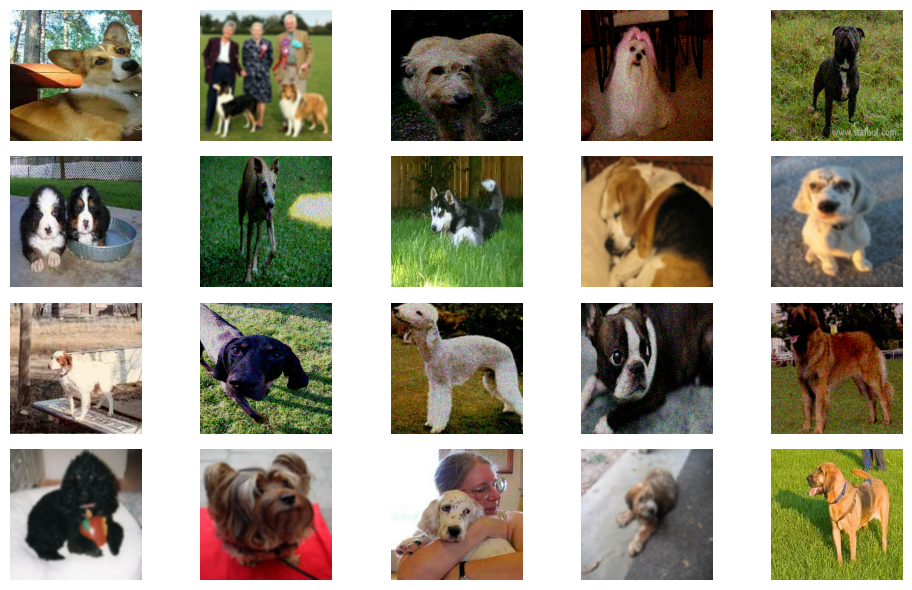

In [20]:
import matplotlib.pyplot as plt

for images, labels in train_variant.take(1):
    plt.figure(figsize=(10, 6))
    for i in range(20):
        plt.subplot(4, 5, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [21]:


eval_df = pd.DataFrame(all_model_results)
print(eval_df.head(30))

      p corruption_type  severity      loss  accuracy      top5
0   0.0           clean       NaN  0.433096  0.864917  0.988095
1   0.0           noise      10.0  0.736626  0.775024  0.961856
2   0.0           noise      20.0  1.001607  0.706997  0.936832
3   0.0           noise      30.0  1.376615  0.613946  0.887755
4   0.0            jpeg      80.0  0.503078  0.839407  0.984451
5   0.0            jpeg      60.0  0.574793  0.815355  0.978134
6   0.0            jpeg      20.0  0.877293  0.729835  0.950680
7   0.0            blur       3.0  0.681314  0.779397  0.967930
8   0.0            blur       5.0  1.038078  0.693635  0.929786
9   0.0            blur       8.0  1.832316  0.520894  0.819971
10  0.5           clean       NaN  0.456663  0.853984  0.986638
11  0.5           noise      10.0  0.677032  0.795918  0.967930
12  0.5           noise      20.0  0.868335  0.739310  0.947765
13  0.5           noise      30.0  1.152028  0.665209  0.910593
14  0.5            jpeg      80.0  0.512

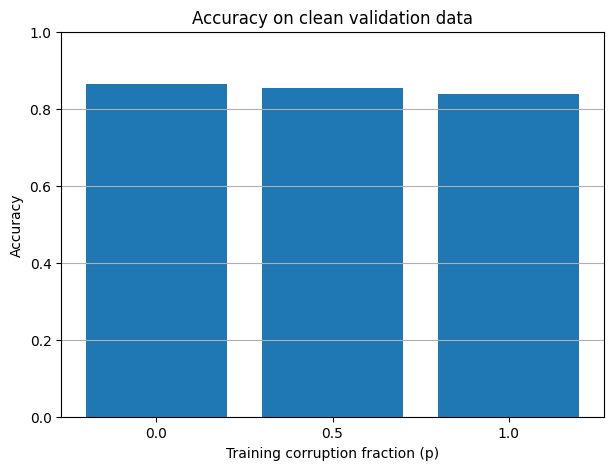

In [22]:
clean_df = eval_df[eval_df["corruption_type"] == "clean"].copy()

plt.figure(figsize=(7,5))
plt.bar(clean_df["p"].astype(str), clean_df["accuracy"])
plt.title("Accuracy on clean validation data")
plt.xlabel("Training corruption fraction (p)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [23]:
def plot_corruption_curve(df, corruption_type, metric="accuracy"):
    subset = df[df["corruption_type"] == corruption_type].copy()

    if corruption_type == "jpeg": # invert severity for jpeg to make plots more intuitive (higher severity = worse quality)
        subset["severity_plot"] = 100 - subset["severity"]
        xlabel = "JPEG severity (100 - quality)"
    else:
        subset["severity_plot"] = subset["severity"]
        xlabel = "Severity"

    plt.figure(figsize=(8, 5))

    for p_value in sorted(subset["p"].unique()): # loop through each training corruption fraction
        run = subset[subset["p"] == p_value].sort_values("severity_plot")
        plt.plot(run["severity_plot"], run[metric], marker="o", label=f"p={p_value}")

    plt.title(f"{metric} when evaluating on {corruption_type}")
    plt.xlabel(xlabel)
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

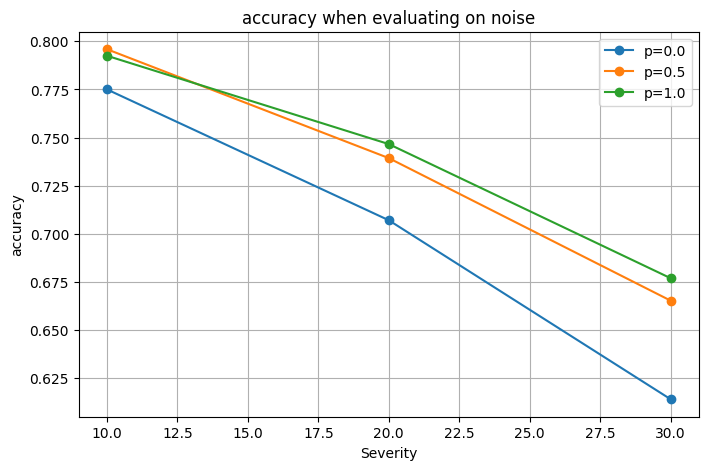

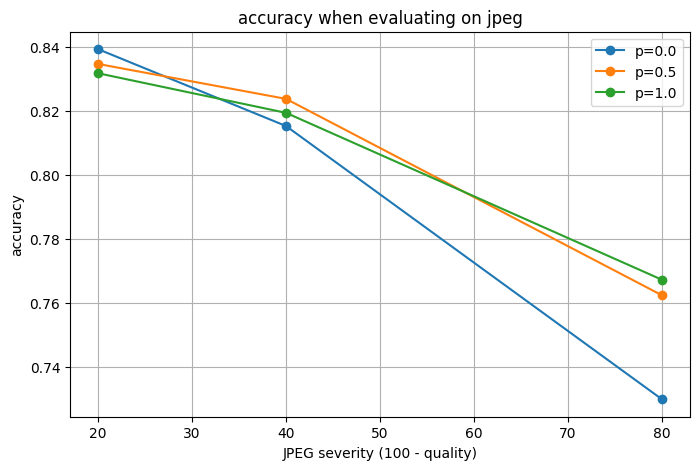

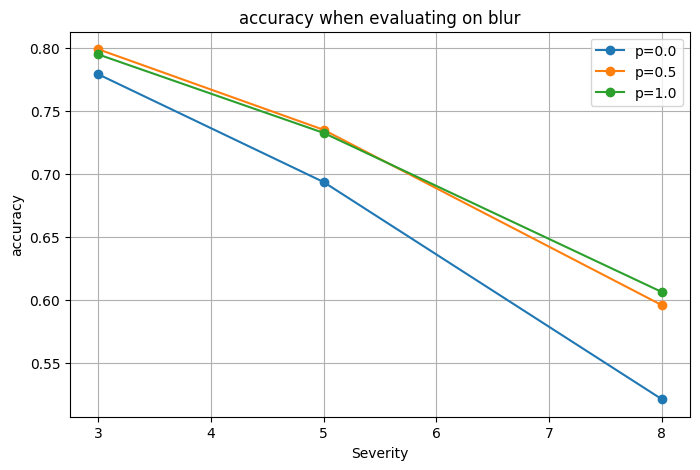

In [24]:
for ctype in ["noise", "jpeg", "blur"]:
    plot_corruption_curve(eval_df, ctype, metric="accuracy")

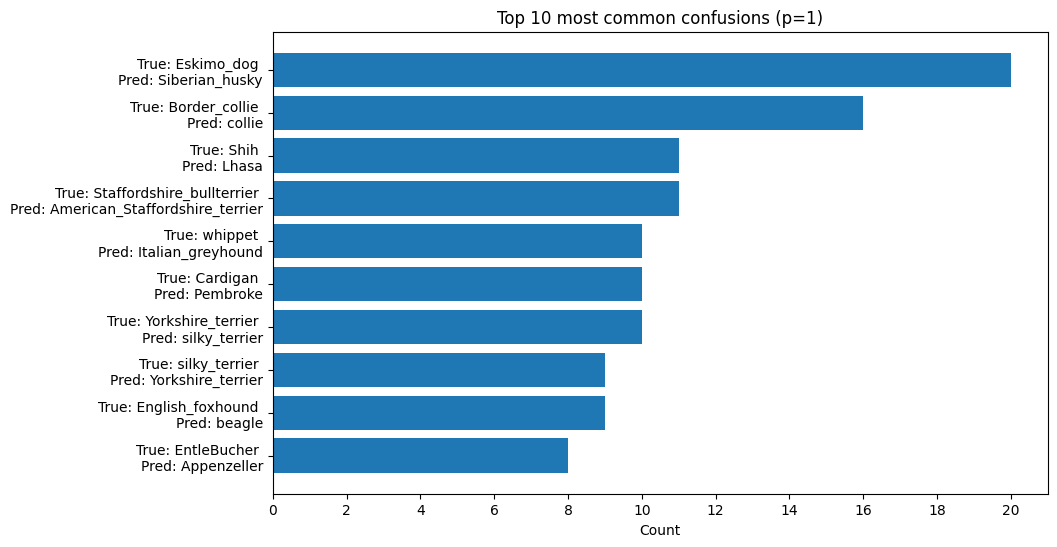

In [28]:
def top_confusions_df(predictions_store, p, class_names, top_n=10):
    run = next(r for r in predictions_store if r["p"] == p) # find the run with the specified p value
    y_true = run["y_true"]
    y_pred = run["y_pred"]

    wrong_pairs = [(t, pred) for t, pred in zip(y_true, y_pred) if t != pred]  # create a list of tuples (true_label, predicted_label) for all misclassified samples
    counts = Counter(wrong_pairs).most_common(top_n) # get the top_n most common confusions and their counts

    rows = []
    for (true_idx, pred_idx), count in counts: 
        rows.append({
            "pair":"True: " f'{class_names[int(true_idx)].split("-")[1]} \nPred: {class_names[int(pred_idx)].split("-")[1]}',
            "count": count
        })
    return pd.DataFrame(rows)

conf_df = top_confusions_df(predictions_store, 1, class_names, top_n=10)

plt.figure(figsize=(10,6))
plt.barh(conf_df["pair"], conf_df["count"])
plt.xticks(np.arange(0,22,2))
plt.title("Top 10 most common confusions (p=1)")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# !taskkill /PID 22700 /F
# %reload_ext tensorboard
# %tensorboard --logdir logs

ERROR: The process "22700" not found.


Reusing TensorBoard on port 6006 (pid 22700), started 4 days, 3:18:42 ago. (Use '!kill 22700' to kill it.)

# Results and findings

When training with 0,50,100 % of pictures corrupted:
* Training accuracy fell with more corrupt data in training data, from 92% to 80%
* While validation accuracy fell when 86.4% to 84%

When evaluating with 3 diffrent amount of corruption 0,50,100% in training data and 3 types of corruption levels: 
* Accuracy decreases when evaluating on images of decreased quality.
* With 100% corruption in training data Accuracy inceases when the severity of the corruption in the validation data increases.